# Chapter 1: The Market Discovers the Future
Seeded synthetic prices illustrate OHLC records, information adjustment and a
holdout comparison. These are not reconstructed Dojima prices. A futures price
also includes carry and risk premia; it is not simply an expected spot price.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from matplotlib.patches import Rectangle
rng=begin(1)

## A candle preserves information a closing price discards

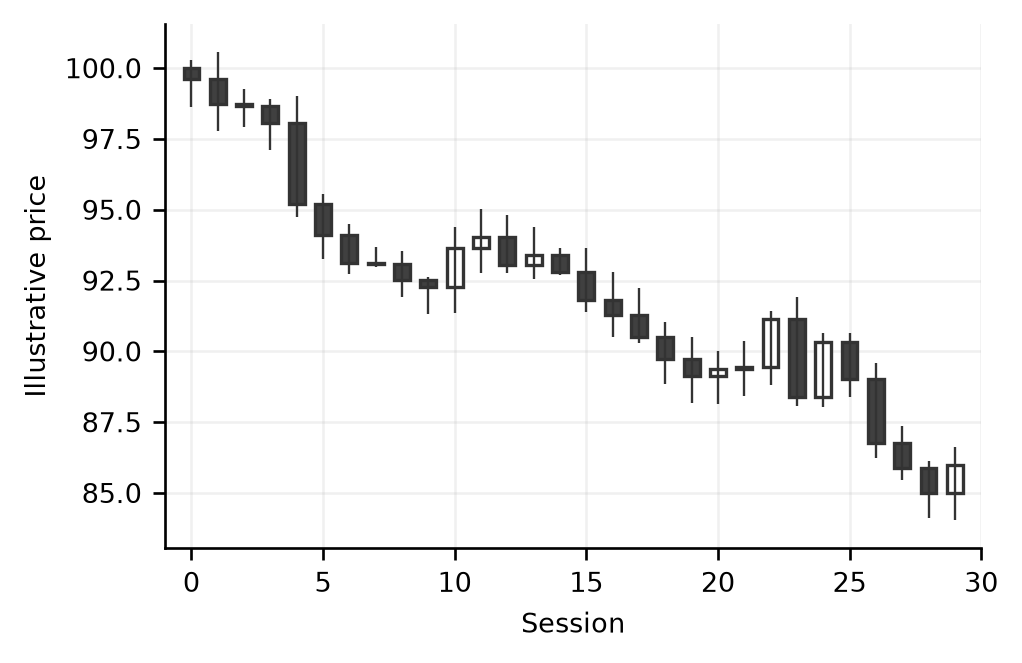

In [2]:
close=100+np.cumsum(rng.normal(0,1,80)); opening=np.r_[100,close[:-1]]
high=np.maximum(opening,close)+rng.uniform(.1,1,80); low=np.minimum(opening,close)-rng.uniform(.1,1,80)
fig,ax=plt.subplots()
for t in range(30):
    ax.vlines(t,low[t],high[t],color='.2',lw=.7)
    ax.add_patch(Rectangle((t-.3,min(opening[t],close[t])),.6,max(.03,abs(close[t]-opening[t])),facecolor='white' if close[t]>opening[t] else '.25',edgecolor='.2'))
ax.set_xlim(-1,30); ax.set_ylim(low[:30].min()-1,high[:30].max()+1); ax.set_xlabel('Session'); ax.set_ylabel('Illustrative price')
save(1,1,'What a price candle records','Synthetic opening, high, low and closing prices. Hollow candles close above the opening; filled candles close below it.','## What the Market Knows')

## Information reaches the market gradually in this toy mechanism

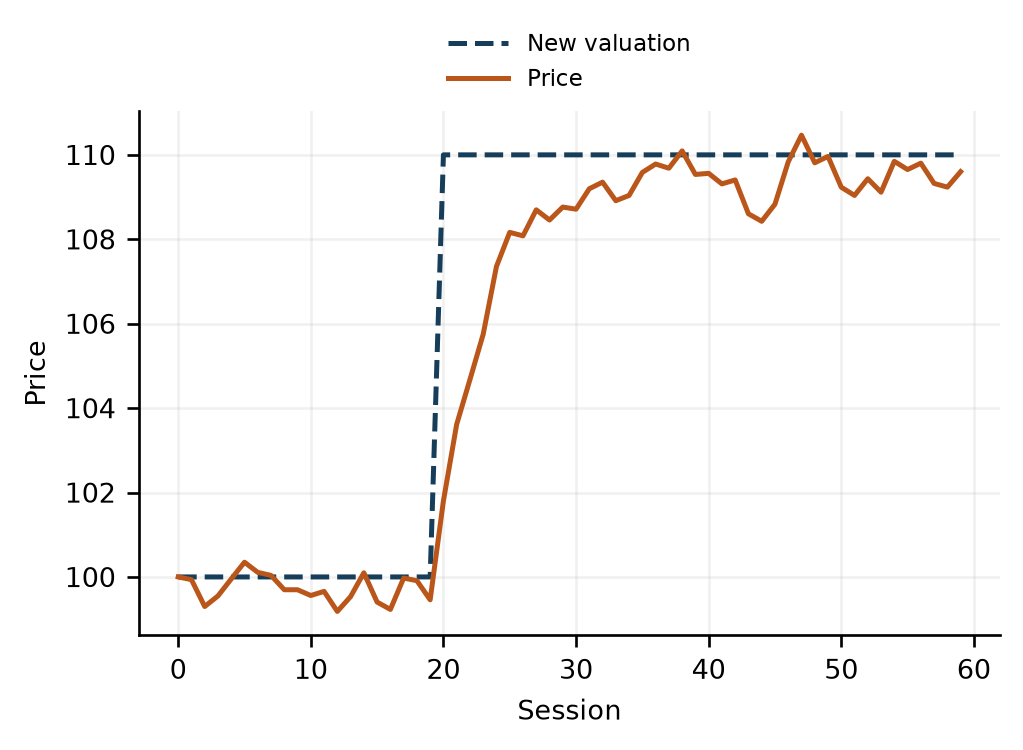

In [3]:
value=np.r_[np.ones(20)*100,np.ones(40)*110]; market=[100.]
for t in range(1,60): market.append(market[-1]+.22*(value[t]-market[-1])+rng.normal(0,.35))
plt.figure(); plt.plot(value,ls='--',label='New valuation'); plt.plot(market,label='Price'); plt.xlabel('Session'); plt.ylabel('Price'); plt.legend()
save(1,2,'Price adjustment after news','Synthetic information shock with partial adjustment and trading noise. The adjustment rule is assumed, not estimated from historical markets.','## Prediction Markets: The Mechanism Generalized')

## Patterns must survive data they did not select
A persistence forecast and a predeclared momentum rule are compared across many
independent random walks. Any apparent single-walk advantage may be chance.

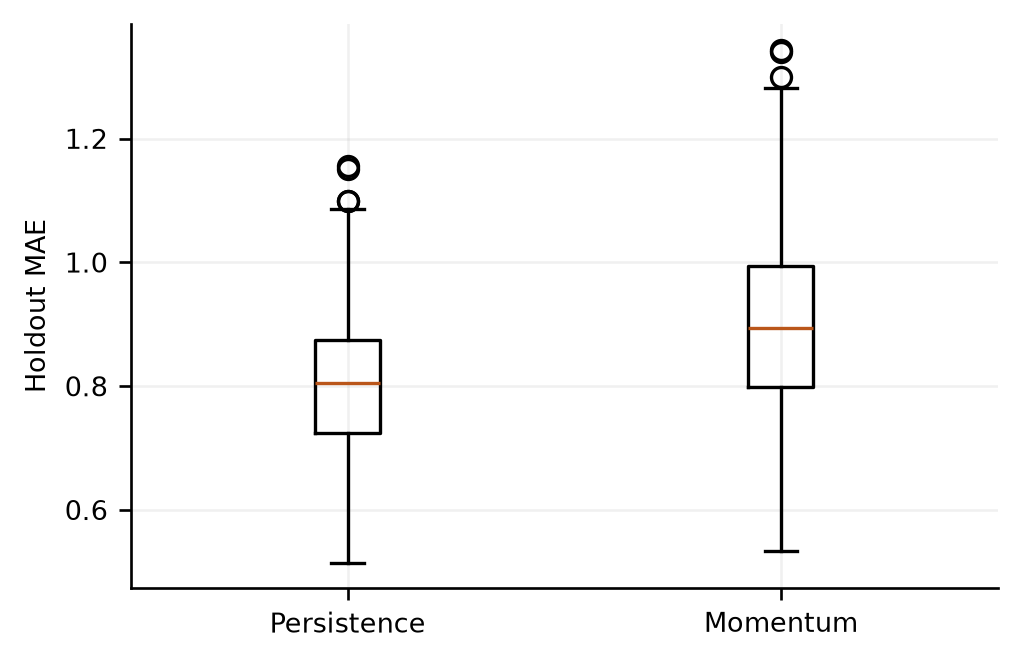

In [4]:
walks=np.cumsum(rng.normal(size=(400,100)),axis=1)
truth=walks[:,70:]; naive=walks[:,69:-1]; momentum=naive+.5*(walks[:,69:-1]-walks[:,68:-2])
errors=[np.mean(abs(truth-p),axis=1) for p in [naive,momentum]]
plt.figure(); plt.boxplot(errors,tick_labels=['Persistence','Momentum']); plt.ylabel('Holdout MAE');
save(1,3,'A plausible pattern needs a benchmark','Four hundred synthetic random walks, with the final thirty observations held out. Momentum is a fixed rule, not tuned on the holdout.','## A Sidebar on Patterns in Numbers')

## Extension and exercise
Benford probabilities are log10(1+1/d), d=1,...,9. They sum to one but do not
apply to every price dataset. Change the generator to correlated returns and
examine whether momentum now earns its place. Prediction-market prices require
assumptions about incentives, risk preferences and trading frictions.

In [5]:
benford=np.log10(1+1/np.arange(1,10)); assert np.isclose(benford.sum(),1)
print('Benford reference probabilities:',benford)

Benford reference probabilities: [0.30103    0.17609126 0.12493874 0.09691001 0.07918125 0.06694679
 0.05799195 0.05115252 0.04575749]


<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
A regular OHLC price series of at least 30 rows with consistent bounds (low at or below open and close, high at or above them). Declare `rules` (the shipped config declares persistence, momentum and mean reversion) before running; `k` is the lookback for momentum and mean reversion and `train_fraction` the share of history reserved before scoring begins.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,open,high,low,close
2010-01-01,100.0,101.7,99.0,100.7
2010-02-01,100.7,102.2,99.7,101.2
```

## Explain the mechanism

A price aggregates information through a market mechanism, but the resulting forecast contains frictions and incentives. OHLC summarizes within-period movement. A visually plausible pattern must beat a predeclared baseline after the information cutoff.

## Work through the arithmetic

If the last two closes are 100 and 103, persistence predicts 103. A one-step extrapolation of the latest change predicts 106. If the next close is 102, absolute errors are 1 and 4. One example favors persistence but does not establish its general superiority.

## Adapt the lesson to reader data

Replace the simulated price/OHLC arrays with an adjusted, single-contract series. Preserve the difference between the partial-adjustment mechanism and the forecasting comparison: assumed information shocks are not measured market fundamentals. Retain a calendar of market sessions, rather than imputing holiday prices as new trades.

For this chapter, settle these questions before fitting: Is the target spot, futures or an event-contract price? What is the quote frequency? When could the signal have been known? Are transaction costs relevant?

## Interpret the actual lesson outputs

Candles depict synthetic ranges. The adjustment plot assumes an information-processing rule; its speed is not estimated from a real market. The repeated random-walk comparison evaluates a prespecified momentum rule on 400 controlled paths, not a trading backtest or proof of market efficiency.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,actual,persistence,momentum,mean_reversion,actual_direction,momentum_hit,mean_reversion_hit`.
- `summary.json`: `rules,k,train_fraction,test_rows,mae,hit_rate,hit_rate_p_value,benford` plus method, interpretation, assumptions, not_done and status.

The tool scores predeclared one-step rules on closing prices at every origin after the training share: persistence (last close), momentum (last close plus the average change over `k` periods) and mean reversion (mean of the last `k` closes). It reports MAE per rule, the directional hit rate of momentum and mean reversion with zero-change periods excluded and a binomial p-value against a coin, and a Benford first-digit chi-square test on `benford_column` as a data-integrity habit. It computes price error only: no returns, costs, position sizing, sessions or corporate-action checks. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Check sensitivity to lookback, corporate-action treatment and quote timing. Futures carry and risk premia prevent a simple expected-spot interpretation. Event-market probabilities additionally need defensible contract resolution and market assumptions. Price forecasts alone do not establish profitable trades.

With close-only data, omit candlesticks and use close-based baselines. Without a reliable adjustment history, segment at discontinuities or state that change forecasts are unreliable. No historical data supports only a mechanism illustration.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,actual,persistence,momentum,mean_reversion,actual_direction,momentum_hit,mean_reversion_hit`; `summary.json` keys: `rules,k,train_fraction,test_rows,mae,hit_rate,hit_rate_p_value,benford` plus method, interpretation, assumptions, not_done and status. A hit rate of 56 percent on 44 observations has a coin-flip p-value near a half; say so before anyone trades on it.

## Three exercises with worked solutions

### Exercise 1

OHLC is 100,99,98,101. Is it valid?

**Worked solution.** No: the reported high 99 is below open 100 and close 101. Correct the record from source or exclude it with a reason.

### Exercise 2

Last close is 80, next actual 77. What is persistence absolute error?

**Worked solution.** The prediction is 80 and absolute error is 3 price units.

### Exercise 3

A momentum lookback was chosen after comparing the last month. Can that month remain final test?

**Worked solution.** No. It is now selection data; evaluate on later untouched observations.

## Business-reader application

Use this request with the skill:

> Use chapter 1 to audit prices.csv and compare a prespecified momentum rule with persistence on later matched observations. Separate prediction error from trading profitability.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [6]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch01.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch01.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(1, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch01-workshop-results.csv', index=False)
_ = (workshop_output/'ch01-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Predeclared one-step price rules with directional hit rates
Status: passed

Interpretation: One-step rules scored on 44 test closes after a 70% training share. MAE: persistence 0.7331, momentum 0.7758, mean_reversion 1.245; best persistence. momentum calls direction 56.8% of the time (binomial p vs coin 0.45). mean_reversion calls direction 43.2% of the time (binomial p vs coin 0.45). Benford first-digit chi-square p on close: 2.8e-60 (prices are not expected to obey Benford; the test is a data-integrity habit, not a signal). Price error is not net return; nothing here is a trading result.

Assumptions:
  - Rules declared before scoring
  - Closing prices are comparable across the sample (no unadjusted splits)
  - Zero-change periods excluded from hit rates
Not done:
  - No returns, transaction costs or position sizing
  - No session or corporate-action checks
  - No out-of-sample period beyond this series

Evidence:
  rules: [persistence, momentum, mean_reversion]
  k: 5
  tra

## Self-check

The three questions a good forecaster asks in this situation. A bad answer to any one of them is a reason to stop and fix the work before reporting.

1. **Was the rule written down before it was scored, and would I have chosen it without seeing these prices?**
   A bad answer looks like this: A rule found by looking at the same prices it is scored on is a description of the past dressed as a forecast.

2. **What does the persistence forecast score on these sessions, and by how much does my rule beat it?**
   A bad answer looks like this: A hit rate near one half, or a margin that a different 30-session window would erase, is no edge.

3. **Have I counted costs, sessions and corporate actions, or am I scoring price error and calling it a return?**
   A bad answer looks like this: A price-error backtest reported as if it were tradeable is the most common way this chapter's lesson is lost.

Shared rules for every chapter: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).